# US 100B+ Oracle Universe Random Forest Notebook

This notebook builds the same oracle entry/exit dataset as the MTL notebook, but trains separate random forest baselines for entry and exit states.

Models trained:
- entry action classifier: `buy` vs `short`
- exit action classifier: `sell` vs `cover`
- entry return regressor: `trade_return_pct`
- exit return regressor: `trade_return_pct`

Time split:
- training uses all data with event date before `2020-01-01`
- out-of-sample evaluation uses `2020-01-01+`


In [1]:
import os

import django
import numpy as np
import pandas as pd
from django.apps import apps
from IPython.display import display
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, f1_score, mean_absolute_error, mean_squared_error, r2_score

os.environ.setdefault("DJANGO_ALLOW_ASYNC_UNSAFE", "true")
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "settings")
if not apps.ready:
    django.setup()

from data.historical_prices import load_adjusted_price_frames
from domain.labels.specs import LabelBuildSpec
from features.feature_builders import build_fundamental_change_features, build_price_technical_features
from features.macro import EconomicDataConfig, broadcast_series_to_daily, fetch_economic_data_series
from fmp.models import EconomicIndicatorSeries, Symbol, TreasuryRateSeries
from pipeline.universe_selection import DEFAULT_US_EXCHANGES, resolve_symbol_universe
from workflows.labels import build_oracle_labels

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [2]:
APP_CFG = {
    "dates": {
        "start_date": "1900-01-01",
        "train_cutoff": "2020-01-01",
        "backtest_start": "2025-01-01",
        "end_date": None,
    },
    "universe": {
        "country": "US",
        "exchanges": list(DEFAULT_US_EXCHANGES),
        "min_market_cap": 10_000_000_000.0,
        "exclude_pooled_vehicles": True,
        "size": None,
    },
    "labels": {
        "k_params": {"YE": [1, 2, 4, 8, 16]},
        "min_profit_pct": 0.50,
        "buy_execution": "adj_high",
        "sell_execution": "adj_low",
        "short_execution": "adj_low",
        "cover_execution": "adj_high",
        "trade_dedup_mode": "exact",
        "download_missing_prices": True,
    },
    "rf": {
        "n_estimators": 200,
        "random_state": 1337,
        "n_jobs": -1,
        "max_depth": 12,
        "max_features": "sqrt",
        "min_samples_leaf": 5,
        "min_samples_split": 2,
        "class_weight": "balanced",
    },
}

TRAIN_CUTOFF = pd.Timestamp(APP_CFG["dates"]["train_cutoff"])
BACKTEST_START = pd.Timestamp(APP_CFG["dates"].get("backtest_start") or APP_CFG["dates"]["train_cutoff"])
APP_CFG


{'dates': {'start_date': '1900-01-01',
  'train_cutoff': '2020-01-01',
  'backtest_start': '2025-01-01',
  'end_date': None},
 'universe': {'country': 'US',
  'exchanges': ['NASDAQ', 'NYSE', 'AMEX'],
  'min_market_cap': 10000000000.0,
  'exclude_pooled_vehicles': True,
  'size': None},
 'labels': {'k_params': {'YE': [1, 2, 4, 8, 16]},
  'min_profit_pct': 0.5,
  'buy_execution': 'adj_high',
  'sell_execution': 'adj_low',
  'short_execution': 'adj_low',
  'cover_execution': 'adj_high',
  'trade_dedup_mode': 'exact',
  'download_missing_prices': True},
 'rf': {'n_estimators': 200,
  'random_state': 1337,
  'n_jobs': -1,
  'max_depth': 12,
  'max_features': 'sqrt',
  'min_samples_leaf': 5,
  'min_samples_split': 2,
  'class_weight': 'balanced'}}

In [3]:
# Setup already defined above; retained as a no-op.


In [4]:
# APP_CFG is defined above with RF settings; retained as a no-op.


In [5]:
universe = tuple(
    resolve_symbol_universe(
        min_market_cap=float(APP_CFG["universe"]["min_market_cap"]),
        country=str(APP_CFG["universe"]["country"]),
        exchanges=list(APP_CFG["universe"]["exchanges"]),
        exclude_pooled_vehicles=bool(APP_CFG["universe"]["exclude_pooled_vehicles"]),
        limit=APP_CFG["universe"]["size"],
    )
)

if not universe:
    raise ValueError("Universe screen returned no symbols.")

symbol_order = {symbol: idx for idx, symbol in enumerate(universe)}
universe_rows = list(
    Symbol.objects.filter(symbol__in=universe)
    .values("symbol", "company_name", "sector", "industry", "exchange", "country", "market_cap", "payload")
)
universe_df = pd.DataFrame(universe_rows)
if not universe_df.empty:
    universe_df["symbol"] = universe_df["symbol"].astype(str).str.strip().str.upper()
    universe_df["sector"] = universe_df["sector"].fillna("").astype(str).str.strip().replace("", "Unknown")
    universe_df["industry"] = universe_df["industry"].fillna("").astype(str).str.strip().replace("", "Unknown")
    universe_df["sort_order"] = universe_df["symbol"].map(symbol_order)
    universe_df["is_etf"] = universe_df["payload"].apply(
        lambda payload: bool((payload or {}).get("isEtf")) if isinstance(payload, dict) else False
    )
    universe_df["is_fund"] = universe_df["payload"].apply(
        lambda payload: bool((payload or {}).get("isFund")) if isinstance(payload, dict) else False
    )
    universe_df = universe_df.sort_values(["sort_order", "symbol"]).drop(columns=["sort_order", "payload"])

universe_summary_df = pd.DataFrame(
    [
        {
            "country": APP_CFG["universe"]["country"],
            "exchanges": ", ".join(APP_CFG["universe"]["exchanges"]),
            "min_market_cap": float(APP_CFG["universe"]["min_market_cap"]),
            "exclude_pooled_vehicles": bool(APP_CFG["universe"]["exclude_pooled_vehicles"]),
            "resolved_symbol_count": int(len(universe)),
            "sample_symbols": ", ".join(universe[:25]),
        }
    ]
)

display(universe_summary_df)
display(universe_df.head(50))
print(f"Universe size: {len(universe)}")


,country,exchanges,min_market_cap,exclude_pooled_vehicles,resolved_symbol_count,sample_symbols
0,US,"NASDAQ, NYSE, AMEX",1.000000e+10,True,762,"GOOG, AVGO, BRK-B, BRK-A, WMT, LLY, JPM, XOM, ..."


,symbol,company_name,sector,industry,exchange,country,market_cap,is_etf,is_fund
318,GOOG,Alphabet Inc.,Communication Services,Internet Content & Information,NASDAQ,US,3.701803e+12,False,False
65,AVGO,Broadcom Inc.,Technology,Semiconductors,NASDAQ,US,1.639295e+12,False,False
103,BRK-B,Berkshire Hathaway Inc.,Financial Services,Insurance - Diversified,NYSE,US,1.072821e+12,False,False
102,BRK-A,Berkshire Hathaway Inc.,Financial Services,Insurance - Diversified,NYSE,US,1.070225e+12,False,False
734,WMT,Walmart Inc.,Consumer Defensive,Specialty Retail,NASDAQ,US,9.913443e+11,False,False
414,LLY,Eli Lilly and Company,Healthcare,Drug Manufacturers - General,NYSE,US,9.510454e+11,False,False
386,JPM,JPMorgan Chase & Co.,Financial Services,Banks - Diversified,NYSE,US,7.818157e+11,False,False
750,XOM,Exxon Mobil Corporation,Energy,Oil & Gas Integrated,NYSE,US,6.268062e+11,False,False
697,V,Visa Inc.,Financial Services,Financial - Credit Services,NYSE,US,6.092991e+11,False,False
384,JNJ,Johnson & Johnson,Healthcare,Drug Manufacturers - General,NYSE,US,5.846174e+11,False,False


Universe size: 762


In [6]:
price_frames = load_adjusted_price_frames(
    list(universe),
    start_date=APP_CFG["dates"]["start_date"],
    end_date=APP_CFG["dates"]["end_date"],
)

price_diagnostics = []
for symbol in universe:
    frame = price_frames.get(symbol, pd.DataFrame())
    price_diagnostics.append(
        {
            "symbol": symbol,
            "price_rows": int(len(frame)),
            "history_start": frame.index.min().strftime("%Y-%m-%d") if not frame.empty else "",
            "history_end": frame.index.max().strftime("%Y-%m-%d") if not frame.empty else "",
            "has_adj_high": bool("adj_high" in frame.columns),
            "has_adj_low": bool("adj_low" in frame.columns),
            "has_adj_close": bool("adj_close" in frame.columns),
        }
    )

price_diagnostics_df = pd.DataFrame(price_diagnostics)

price_lookup_rows = []
for symbol in universe:
    frame = price_frames.get(symbol, pd.DataFrame())
    if frame.empty:
        continue
    working = frame.reset_index().copy()
    working["symbol"] = symbol
    working["date_text"] = pd.to_datetime(working["date"], errors="coerce").dt.strftime("%Y-%m-%d")
    for row in working.to_dict(orient="records"):
        price_lookup_rows.append(
            {
                "symbol": str(row.get("symbol") or "").strip().upper(),
                "date_text": str(row.get("date_text") or ""),
                "adj_open": row.get("adj_open"),
                "adj_high": row.get("adj_high"),
                "adj_low": row.get("adj_low"),
                "adj_close": row.get("adj_close"),
                "volume": row.get("volume"),
            }
        )

price_lookup_df = pd.DataFrame(price_lookup_rows)
if not price_lookup_df.empty:
    for col in ["adj_open", "adj_high", "adj_low", "adj_close", "volume"]:
        price_lookup_df[col] = pd.to_numeric(price_lookup_df[col], errors="coerce")
    price_lookup_df = price_lookup_df.drop_duplicates(subset=["symbol", "date_text"], keep="last").reset_index(drop=True)
display(price_diagnostics_df.head(50))
print(
    "Symbols with adjusted price history:",
    int((price_diagnostics_df["price_rows"] > 0).sum()),
    "/",
    len(price_diagnostics_df),
)

,symbol,price_rows,history_start,history_end,has_adj_high,has_adj_low,has_adj_close
0,GOOG,5421,2004-08-19,2026-03-06,True,True,True
1,AVGO,4171,2009-08-06,2026-03-06,True,True,True
2,BRK-B,7504,1996-05-09,2026-03-06,True,True,True
3,BRK-A,11587,1980-03-17,2026-03-06,True,True,True
4,WMT,13595,1972-04-03,2026-03-06,True,True,True
5,LLY,14034,1970-07-09,2026-03-06,True,True,True
6,JPM,14373,1969-03-05,2026-03-06,True,True,True
7,XOM,16152,1962-01-02,2026-03-06,True,True,True
8,V,4520,2008-03-19,2026-03-06,True,True,True
9,JNJ,14165,1970-01-02,2026-03-06,True,True,True


Symbols with adjusted price history: 761 / 762


In [7]:
label_spec = LabelBuildSpec(
    k_params=dict(APP_CFG["labels"]["k_params"]),
    min_profit_pct=float(APP_CFG["labels"]["min_profit_pct"]),
    buy_execution=str(APP_CFG["labels"]["buy_execution"]),
    sell_execution=str(APP_CFG["labels"]["sell_execution"]),
    short_execution=str(APP_CFG["labels"]["short_execution"]),
    cover_execution=str(APP_CFG["labels"]["cover_execution"]),
    trade_dedup_mode=str(APP_CFG["labels"]["trade_dedup_mode"]),
    start_date=APP_CFG["dates"]["start_date"],
    end_date=APP_CFG["dates"]["end_date"],
    download_missing_prices=bool(APP_CFG["labels"]["download_missing_prices"]),
)

oracle_result = build_oracle_labels(
    list(universe),
    spec=label_spec,
    price_frames=price_frames,
)

label_df = pd.DataFrame(oracle_result.label_rows)
completed_trades_df = pd.DataFrame(oracle_result.completed_trades)
stats_df = pd.DataFrame([oracle_result.statistics.get("trade_stats", {})])
grouped_stats_df = pd.DataFrame(oracle_result.statistics.get("grouped_trade_stats", []))

if not label_df.empty:
    label_df["date"] = pd.to_datetime(label_df["date"], errors="coerce")
    label_df["entry_date"] = pd.to_datetime(label_df["entry_date"], errors="coerce")
    label_df["exit_date"] = pd.to_datetime(label_df["exit_date"], errors="coerce")
    label_df["trade_return"] = pd.to_numeric(label_df["trade_return"], errors="coerce")
    label_df["hold_days"] = pd.to_numeric(label_df.get("hold_days"), errors="coerce")
    if "trade_duration_days" in label_df.columns:
        label_df["trade_duration_days"] = pd.to_numeric(label_df["trade_duration_days"], errors="coerce")
    label_df["k"] = pd.to_numeric(label_df["k"], errors="coerce").astype("Int64")
    if "trade_id" in label_df.columns:
        label_df["trade_id"] = label_df["trade_id"].astype(str)
    if "event" in label_df.columns:
        label_df["event"] = label_df["event"].fillna("").astype(str).str.strip().str.lower()
    if "action_label" in label_df.columns:
        label_df["action_label"] = label_df["action_label"].fillna("").astype(str).str.strip().str.lower()
    elif "label" in label_df.columns:
        label_df["action_label"] = label_df["label"].fillna("").astype(str).str.strip().str.lower()

if not completed_trades_df.empty:
    completed_trades_df["entry_date"] = pd.to_datetime(completed_trades_df["entry_date"], errors="coerce")
    completed_trades_df["exit_date"] = pd.to_datetime(completed_trades_df["exit_date"], errors="coerce")
    completed_trades_df["ret_dec"] = pd.to_numeric(completed_trades_df["ret_dec"], errors="coerce")
    completed_trades_df["hold_days"] = pd.to_numeric(completed_trades_df["hold_days"], errors="coerce")
    completed_trades_df["k"] = pd.to_numeric(completed_trades_df["k"], errors="coerce").astype("Int64")

display(pd.DataFrame([label_spec.__dict__]))
display(stats_df)
display(grouped_stats_df)
print(f"Label rows: {len(label_df):,}")
print(f"Completed trades: {len(completed_trades_df):,}")


,k_params,solver_mode,min_profit_pct,buy_execution,sell_execution,short_execution,cover_execution,trade_dedup_mode,start_date,end_date,download_missing_prices
0,"{'YE': [1, 2, 4, 8, 16]}",period_top_k,0.5,adj_high,adj_low,adj_low,adj_high,exact,1900-01-01,None,True


,total_trades,symbols_count,long_trades,short_trades,winning_trades,losing_trades,breakeven_trades,win_rate_pct,loss_rate_pct,avg_return_pct,median_return_pct
0,15078,728,12084,2994,15078,0,0,100.0,0.0,99.2474,68.9662


,side,freq,k,trades,trade_return_mean_pct,trade_return_std_pct,trade_duration_mean,trade_duration_std,sharpe
0,long,YE,1,7187,107.0944,187.5787,249.4259,84.0605,0.570930
1,long,YE,2,2678,113.4744,225.3486,118.2001,66.7460,0.503551
2,long,YE,4,1873,94.9597,179.6588,86.3027,57.3863,0.528556
3,long,YE,8,299,128.4045,316.2538,41.6455,39.0442,0.406017
4,long,YE,16,47,362.2195,647.6062,13.2766,14.6669,0.559321
5,short,YE,1,1583,63.4251,10.7359,211.3020,89.3324,5.907744
6,short,YE,2,841,62.8816,10.7987,132.0809,77.6553,5.823091
7,short,YE,4,450,62.9195,10.8958,104.8178,66.1243,5.774660
8,short,YE,8,103,64.4807,13.4185,59.5340,41.4851,4.805362
9,short,YE,16,17,80.1800,16.7441,18.0000,22.7679,4.788563


Label rows: 30,156
Completed trades: 15,078


In [8]:
if completed_trades_df.empty:
    raise ValueError("No completed trades were generated for the current config.")

trade_summary_df = (
    completed_trades_df.groupby(["side", "freq", "k"], as_index=False)
    .agg(
        trades=("symbol", "count"),
        avg_return_pct=("ret_dec", lambda series: series.mean() * 100.0),
        median_return_pct=("ret_dec", lambda series: series.median() * 100.0),
        avg_hold_days=("hold_days", "mean"),
    )
    .sort_values(["side", "freq", "k"])
    .reset_index(drop=True)
)

top_trades_df = completed_trades_df.sort_values("ret_dec", ascending=False).head(25).reset_index(drop=True)
recent_trades_df = completed_trades_df.sort_values(["entry_date", "symbol", "side"]).tail(25).reset_index(drop=True)

display(trade_summary_df)
display(top_trades_df)
display(recent_trades_df)
display(label_df.head(25))


,side,freq,k,trades,avg_return_pct,median_return_pct,avg_hold_days
0,long,YE,1,7187,107.094374,74.584323,249.425908
1,long,YE,2,2678,113.474449,75.539445,118.200149
2,long,YE,4,1873,94.959736,67.484663,86.302723
3,long,YE,8,299,128.404461,69.467213,41.645485
4,long,YE,16,47,362.219507,60.714286,13.276596
5,short,YE,1,1583,63.425091,60.765152,211.301958
6,short,YE,2,841,62.881626,60.000000,132.080856
7,short,YE,4,450,62.919548,60.371215,104.817778
8,short,YE,8,103,64.480674,60.820896,59.533981
9,short,YE,16,17,80.179960,90.172642,18.000000


,symbol,side,freq,k,entry_date,exit_date,entry_px,exit_px,ret_dec,hold_days
0,RGLD,long,YE,1,1992-01-03,1992-12-30,0.0235,2.2600,95.230900,362
1,VTRS,long,YE,1,1981-01-26,1981-08-10,0.0280,1.8400,64.771601,196
2,VTRS,long,YE,2,1981-02-09,1981-08-10,0.0280,1.8400,64.771601,182
3,RGLD,long,YE,2,1992-01-03,1992-09-28,0.0235,1.3200,55.205658,269
4,EHC,long,YE,2,2003-03-31,2003-12-15,0.2923,15.1000,50.664557,259
5,EHC,long,YE,1,2003-03-28,2003-12-15,0.2923,15.1000,50.664557,262
6,VTRS,long,YE,4,1981-05-12,1981-08-10,0.0490,1.8400,36.583772,90
7,EHC,long,YE,4,2003-03-31,2003-09-02,0.2923,10.7200,35.678414,155
8,VTRS,long,YE,1,1980-04-17,1980-07-18,0.0280,1.0100,35.102890,92
9,VTRS,long,YE,4,1980-04-17,1980-06-23,0.0280,0.9861,34.250004,67


,symbol,side,freq,k,entry_date,exit_date,entry_px,exit_px,ret_dec,hold_days
0,RCB,short,YE,4,2026-01-26,2026-02-03,24.6500,9.5000,0.614604,8
1,BIPI,short,YE,1,2026-01-27,2026-02-17,17.0500,7.3800,0.567155,21
2,SOJD,short,YE,2,2026-01-27,2026-03-02,20.5400,5.9100,0.712269,34
3,SOJE,short,YE,1,2026-01-27,2026-02-26,18.3300,5.9800,0.673759,30
4,SOJE,short,YE,2,2026-01-27,2026-02-25,18.3300,5.9900,0.673213,29
5,OXLCI,short,YE,1,2026-01-28,2026-02-09,25.8800,7.8100,0.698223,12
6,BNJ,short,YE,1,2026-01-30,2026-02-03,15.7100,7.0900,0.548695,4
7,SOJC,short,YE,2,2026-02-02,2026-02-25,21.8800,5.8400,0.733090,23
8,BNJ,long,YE,2,2026-02-04,2026-03-06,7.0900,15.2600,1.152327,30
9,RCB,short,YE,4,2026-02-04,2026-03-04,24.6200,6.8400,0.722177,28


,date,event,label,action_label,market_position,symbol,trade_id,direction_label,trade_return,hold_days,trade_duration_days,side,freq,k,horizon,entry_date,exit_date,entry_px,exit_px,ret_pct
0,2004-09-03,entry,buy,buy,1,GOOG,T|GOOG|E20040903|X20041102|Slong|HYE_k1,1,0.904382,60,60,long,YE,1,YE_k1,2004-09-03,2004-11-02,2.5100,4.7800,90.44%
1,2004-11-02,exit,sell,sell,0,GOOG,T|GOOG|E20040903|X20041102|Slong|HYE_k1,1,0.904382,60,60,long,YE,1,YE_k1,2004-09-03,2004-11-02,2.5100,4.7800,90.44%
2,2005-03-14,entry,buy,buy,1,GOOG,T|GOOG|E20050314|X20051223|Slong|HYE_k1,1,1.403628,284,284,long,YE,1,YE_k1,2005-03-14,2005-12-23,4.4100,10.6000,140.36%
3,2005-12-23,exit,sell,sell,0,GOOG,T|GOOG|E20050314|X20051223|Slong|HYE_k1,1,1.403628,284,284,long,YE,1,YE_k1,2005-03-14,2005-12-23,4.4100,10.6000,140.36%
4,2007-03-05,entry,buy,buy,1,GOOG,T|GOOG|E20070305|X20071106|Slong|HYE_k1,1,0.626134,246,246,long,YE,1,YE_k1,2007-03-05,2007-11-06,11.0200,17.9200,62.61%
5,2007-11-06,exit,sell,sell,0,GOOG,T|GOOG|E20070305|X20071106|Slong|HYE_k1,1,0.626134,246,246,long,YE,1,YE_k1,2007-03-05,2007-11-06,11.0200,17.9200,62.61%
6,2008-01-02,entry,short,short,-1,GOOG,T|GOOG|E20080102|X20081121|Sshort|HYE_k1,0,0.602388,324,324,short,YE,1,YE_k1,2008-01-02,2008-11-21,16.7500,6.6600,60.24%
7,2008-11-21,exit,cover,cover,0,GOOG,T|GOOG|E20080102|X20081121|Sshort|HYE_k1,0,0.602388,324,324,short,YE,1,YE_k1,2008-01-02,2008-11-21,16.7500,6.6600,60.24%
8,2009-01-20,entry,buy,buy,1,GOOG,T|GOOG|E20090120|X20091231|Slong|HYE_k1,1,1.067476,345,345,long,YE,1,YE_k1,2009-01-20,2009-12-31,7.4100,15.3200,106.75%
9,2009-12-31,exit,sell,sell,0,GOOG,T|GOOG|E20090120|X20091231|Slong|HYE_k1,1,1.067476,345,345,long,YE,1,YE_k1,2009-01-20,2009-12-31,7.4100,15.3200,106.75%


In [9]:
from analysis.oracle_entry_exit_dataset import (
    ENTRY_NUMERIC_COLS,
    EXIT_NUMERIC_COLS,
    STATE_NUMERIC_COLS,
    build_oracle_entry_exit_frames,
)
from features.financial_growth_features import build_financial_growth_features
from features.section_utils import prime_section_record_cache

trade_pair_df, state_df = build_oracle_entry_exit_frames(
    universe_df=universe_df,
    label_df=label_df,
    completed_trades_df=completed_trades_df,
    price_lookup_df=price_lookup_df,
)

unique_symbols = sorted([str(value).strip().upper() for value in state_df["symbol"].dropna().unique() if str(value).strip()])
symbol_obj_rows = list(Symbol.objects.filter(symbol__in=unique_symbols).only("id", "symbol"))
symbol_obj_map = {str(item.symbol).strip().upper(): item for item in symbol_obj_rows}
prime_section_record_cache(symbol_obj_rows, ["key_metrics", "ratios", "financial_growth"])

fundamental_frames = []
fundamental_source_rows = []
technical_frames = []
technical_source_rows = []
for symbol in unique_symbols:
    symbol_obj = symbol_obj_map.get(symbol)
    if symbol_obj is None:
        continue

    symbol_date_values = state_df.loc[state_df["symbol"] == symbol, "date_text"].dropna().astype(str).unique().tolist()
    symbol_dates = pd.DatetimeIndex(pd.to_datetime(symbol_date_values, errors="coerce")).dropna().normalize().unique().sort_values()
    if len(symbol_dates) == 0:
        continue

    target_index = pd.MultiIndex.from_arrays(
        [symbol_dates, [symbol] * len(symbol_dates)],
        names=["date", "symbol"],
    )

    df_prices_symbol = price_frames.get(symbol, pd.DataFrame()).copy()
    if not df_prices_symbol.empty and "adj_close" in df_prices_symbol.columns and "close" not in df_prices_symbol.columns:
        df_prices_symbol = df_prices_symbol.rename(columns={"adj_close": "close"})

    merged_symbol_features = pd.DataFrame(index=target_index)
    selected_feature_cols = []

    technical_built = build_price_technical_features(symbol, df_prices_symbol) if not df_prices_symbol.empty else None
    if technical_built is not None and not technical_built.df.empty and technical_built.feature_cols:
        technical_aligned = technical_built.df.reindex(target_index)
        merged_symbol_features = merged_symbol_features.join(
            technical_aligned[technical_built.feature_cols],
            how="left",
        )
        selected_feature_cols.extend(list(technical_built.feature_cols))

    fundamental_built = build_fundamental_change_features(
        symbol_obj,
        target_index,
        df_prices=df_prices_symbol if not df_prices_symbol.empty else None,
    )
    if not fundamental_built.df.empty and fundamental_built.feature_cols:
        merged_symbol_features = merged_symbol_features.join(
            fundamental_built.df[fundamental_built.feature_cols],
            how="left",
        )
        selected_feature_cols.extend(list(fundamental_built.feature_cols))

    financial_growth_built = build_financial_growth_features(symbol_obj, target_index)
    if not financial_growth_built.df.empty and financial_growth_built.feature_cols:
        merged_symbol_features = merged_symbol_features.join(
            financial_growth_built.df[financial_growth_built.feature_cols],
            how="left",
        )
        selected_feature_cols.extend(list(financial_growth_built.feature_cols))

    selected_feature_cols = list(dict.fromkeys(selected_feature_cols))
    if not selected_feature_cols:
        continue

    technical_source_rows.append(
        {
            "symbol": symbol,
            "technical_cols": sum(1 for col in selected_feature_cols if str(col).startswith("px__")),
        }
    )
    fundamental_source_rows.append(
        {
            "symbol": symbol,
            "feature_cols": len(selected_feature_cols),
            "technical_cols": sum(1 for col in selected_feature_cols if str(col).startswith("px__")),
            "key_metrics_cols": sum(1 for col in selected_feature_cols if str(col).startswith("km__")),
            "ratios_cols": sum(1 for col in selected_feature_cols if str(col).startswith("rt__")),
            "financial_growth_cols": sum(1 for col in selected_feature_cols if str(col).startswith("fg__")),
        }
    )
    symbol_feature_df = merged_symbol_features[selected_feature_cols].reset_index()
    symbol_feature_df["date_text"] = pd.to_datetime(symbol_feature_df["date"], errors="coerce").dt.strftime("%Y-%m-%d")
    fundamental_frames.append(symbol_feature_df[["symbol", "date_text", *selected_feature_cols]])

if fundamental_frames:
    combined_symbol_feature_df = pd.concat(fundamental_frames, ignore_index=True)
    TECHNICAL_FEATURE_COLS = sorted(
        [
            col for col in combined_symbol_feature_df.columns
            if str(col).startswith("px__")
        ]
    )
    TECHNICAL_FEATURE_COLS = [
        col for col in TECHNICAL_FEATURE_COLS
        if col not in {"px__adj_open", "px__adj_high", "px__adj_low", "px__adj_close"}
    ]
    FUNDAMENTAL_FEATURE_COLS = sorted(
        [
            col for col in combined_symbol_feature_df.columns
            if str(col).startswith(("km__", "rt__", "fg__"))
        ]
    )
    symbol_feature_lookup_df = combined_symbol_feature_df[["symbol", "date_text", *TECHNICAL_FEATURE_COLS, *FUNDAMENTAL_FEATURE_COLS]].copy()
    for col in TECHNICAL_FEATURE_COLS + FUNDAMENTAL_FEATURE_COLS:
        symbol_feature_lookup_df[col] = pd.to_numeric(symbol_feature_lookup_df[col], errors="coerce")
else:
    TECHNICAL_FEATURE_COLS = []
    FUNDAMENTAL_FEATURE_COLS = []
    symbol_feature_lookup_df = pd.DataFrame(columns=["symbol", "date_text"])

KM_FEATURE_COLS = [col for col in FUNDAMENTAL_FEATURE_COLS if str(col).startswith("km__")]
RATIO_FEATURE_COLS = [col for col in FUNDAMENTAL_FEATURE_COLS if str(col).startswith("rt__")]
FG_FEATURE_COLS = [col for col in FUNDAMENTAL_FEATURE_COLS if str(col).startswith("fg__")]

all_macro_dates = pd.to_datetime(
    pd.concat(
        [
            state_df["date_text"],
            trade_pair_df["entry_date_text"],
            trade_pair_df["exit_date_text"],
        ],
        axis=0,
        ignore_index=True,
    ),
    errors="coerce",
).dropna()
if len(all_macro_dates) > 0:
    macro_start = all_macro_dates.min().date().isoformat()
    macro_end = all_macro_dates.max().date().isoformat()
else:
    macro_start = None
    macro_end = None

if macro_start and macro_end:
    economic_series_codes = tuple(str(code) for code in EconomicIndicatorSeries.objects.order_by("code").values_list("code", flat=True))
    treasury_series_codes = tuple(str(code) for code in TreasuryRateSeries.objects.order_by("code").values_list("code", flat=True))

    economic_df = fetch_economic_data_series(
        api_key="",
        start_date=macro_start,
        end_date=macro_end,
        config=EconomicDataConfig(
            economic_indicator_series=economic_series_codes,
            include_treasury_rates=False,
        ),
    )
    treasury_df = fetch_economic_data_series(
        api_key="",
        start_date=macro_start,
        end_date=macro_end,
        config=EconomicDataConfig(
            economic_indicator_series=treasury_series_codes,
            include_treasury_rates=False,
        ),
    )
else:
    economic_df = pd.DataFrame()
    treasury_df = pd.DataFrame()

macro_target_index = pd.MultiIndex.from_arrays(
    [pd.to_datetime(state_df["date_text"], errors="coerce"), state_df["symbol"].astype(str)],
    names=["date", "symbol"],
)

economic_daily = broadcast_series_to_daily(economic_df, macro_target_index) if not economic_df.empty else pd.DataFrame(index=macro_target_index)
treasury_daily = broadcast_series_to_daily(treasury_df, macro_target_index) if not treasury_df.empty else pd.DataFrame(index=macro_target_index)
ECONOMIC_FEATURE_COLS = [str(col) for col in list(economic_daily.columns)]
TREASURY_FEATURE_COLS = [str(col) for col in list(treasury_daily.columns)]
MACRO_FEATURE_COLS = ECONOMIC_FEATURE_COLS + TREASURY_FEATURE_COLS

if MACRO_FEATURE_COLS:
    macro_lookup_df = pd.concat([economic_daily, treasury_daily], axis=1).reset_index()
    macro_lookup_df["date_text"] = pd.to_datetime(macro_lookup_df["date"], errors="coerce").dt.strftime("%Y-%m-%d")
    macro_lookup_df = macro_lookup_df[["date_text", *MACRO_FEATURE_COLS]].copy()
    for col in MACRO_FEATURE_COLS:
        macro_lookup_df[col] = pd.to_numeric(macro_lookup_df[col], errors="coerce")
    macro_lookup_df = macro_lookup_df.groupby("date_text", as_index=False).last()
else:
    macro_lookup_df = pd.DataFrame(columns=["date_text"])

state_df = state_df.merge(symbol_feature_lookup_df, on=["symbol", "date_text"], how="left")
for col in TECHNICAL_FEATURE_COLS + FUNDAMENTAL_FEATURE_COLS:
    state_df[col] = pd.to_numeric(state_df[col], errors="coerce")
state_df = state_df.merge(macro_lookup_df, on="date_text", how="left")
for col in MACRO_FEATURE_COLS:
    state_df[col] = pd.to_numeric(state_df[col], errors="coerce")

entry_symbol_feature_lookup_df = symbol_feature_lookup_df.rename(
    columns={
        "date_text": "entry_date_text",
        **{col: f"entry_{col}" for col in TECHNICAL_FEATURE_COLS + FUNDAMENTAL_FEATURE_COLS},
    }
)
exit_symbol_feature_lookup_df = symbol_feature_lookup_df.rename(
    columns={
        "date_text": "exit_date_text",
        **{col: f"exit_{col}" for col in TECHNICAL_FEATURE_COLS + FUNDAMENTAL_FEATURE_COLS},
    }
)
trade_pair_df = trade_pair_df.merge(entry_symbol_feature_lookup_df, on=["symbol", "entry_date_text"], how="left")
trade_pair_df = trade_pair_df.merge(exit_symbol_feature_lookup_df, on=["symbol", "exit_date_text"], how="left")
ENTRY_TECHNICAL_COLS = [f"entry_{col}" for col in TECHNICAL_FEATURE_COLS]
EXIT_TECHNICAL_COLS = [f"exit_{col}" for col in TECHNICAL_FEATURE_COLS]
ENTRY_FUNDAMENTAL_COLS = [f"entry_{col}" for col in FUNDAMENTAL_FEATURE_COLS]
EXIT_FUNDAMENTAL_COLS = [f"exit_{col}" for col in FUNDAMENTAL_FEATURE_COLS]
for col in ENTRY_TECHNICAL_COLS + EXIT_TECHNICAL_COLS + ENTRY_FUNDAMENTAL_COLS + EXIT_FUNDAMENTAL_COLS:
    trade_pair_df[col] = pd.to_numeric(trade_pair_df[col], errors="coerce")

entry_macro_lookup_df = macro_lookup_df.rename(
    columns={"date_text": "entry_date_text", **{col: f"entry_{col}" for col in MACRO_FEATURE_COLS}}
)
exit_macro_lookup_df = macro_lookup_df.rename(
    columns={"date_text": "exit_date_text", **{col: f"exit_{col}" for col in MACRO_FEATURE_COLS}}
)
trade_pair_df = trade_pair_df.merge(entry_macro_lookup_df, on="entry_date_text", how="left")
trade_pair_df = trade_pair_df.merge(exit_macro_lookup_df, on="exit_date_text", how="left")
ENTRY_MACRO_COLS = [f"entry_{col}" for col in MACRO_FEATURE_COLS]
EXIT_MACRO_COLS = [f"exit_{col}" for col in MACRO_FEATURE_COLS]
for col in ENTRY_MACRO_COLS + EXIT_MACRO_COLS:
    trade_pair_df[col] = pd.to_numeric(trade_pair_df[col], errors="coerce")

raw_trade_row_count = int(len(trade_pair_df))
trade_pair_df = trade_pair_df.sort_values(["entry_date", "exit_date", "symbol", "side", "trade_id"]).drop_duplicates(
    subset=["symbol", "entry_date_text", "exit_date_text", "side", "ret_dec"],
    keep="first",
).reset_index(drop=True)

fundamental_source_df = pd.DataFrame(fundamental_source_rows)
technical_source_df = pd.DataFrame(technical_source_rows)
fundamental_summary_df = pd.DataFrame(
    [
        {
            "symbols_with_fundamentals": int(fundamental_source_df["symbol"].nunique()) if not fundamental_source_df.empty else 0,
            "technical_cols": int(len(TECHNICAL_FEATURE_COLS)),
            "key_metrics_cols": int(len(KM_FEATURE_COLS)),
            "ratios_cols": int(len(RATIO_FEATURE_COLS)),
            "financial_growth_cols": int(len(FG_FEATURE_COLS)),
            "economic_indicator_cols": int(len(ECONOMIC_FEATURE_COLS)),
            "treasury_rate_cols": int(len(TREASURY_FEATURE_COLS)),
            "total_symbol_feature_cols": int(len(TECHNICAL_FEATURE_COLS) + len(FUNDAMENTAL_FEATURE_COLS)),
            "total_fundamental_cols": int(len(FUNDAMENTAL_FEATURE_COLS)),
            "total_macro_cols": int(len(MACRO_FEATURE_COLS)),
        }
    ]
)

preview_state_cols = [
    "trade_id",
    "symbol",
    "date_text",
    "event_role",
    "action",
    "direction_label",
    *STATE_NUMERIC_COLS,
]
preview_state_cols += TECHNICAL_FEATURE_COLS[:10]
preview_state_cols += FUNDAMENTAL_FEATURE_COLS[:10]
preview_state_cols += MACRO_FEATURE_COLS[:10]
preview_state_cols += ["trade_return_pct", "hold_days", "text"]
preview_pair_cols = [
    "trade_id",
    "symbol",
    "side",
    "entry_date_text",
    "exit_date_text",
    *ENTRY_NUMERIC_COLS,
    *EXIT_NUMERIC_COLS,
]
preview_pair_cols += ENTRY_TECHNICAL_COLS[:5]
preview_pair_cols += EXIT_TECHNICAL_COLS[:5]
preview_pair_cols += ENTRY_FUNDAMENTAL_COLS[:5]
preview_pair_cols += EXIT_FUNDAMENTAL_COLS[:5]
preview_pair_cols += ENTRY_MACRO_COLS[:3]
preview_pair_cols += EXIT_MACRO_COLS[:3]
preview_pair_cols += ["trade_return_pct", "signed_trade_return_pct", "hold_days", "duration_pct", "inverse_duration_pct"]
preview_pair_cols = [col for col in preview_pair_cols if col in trade_pair_df.columns]

display(state_df[preview_state_cols].head(20))
display(state_df.groupby(["event_role", "action", "direction_label"], as_index=False).size())
display(trade_pair_df[[col for col in preview_pair_cols if col in trade_pair_df.columns]].head(20))
display(fundamental_summary_df)
if not fundamental_source_df.empty:
    display(fundamental_source_df.head(20))
print(f"State numeric cols: {STATE_NUMERIC_COLS}")
print(f"Pair entry numeric cols: {ENTRY_NUMERIC_COLS}")
print(f"Pair exit numeric cols: {EXIT_NUMERIC_COLS}")
print(f"Technical cols: {len(TECHNICAL_FEATURE_COLS):,}")
print(f"Fundamental cols: {len(FUNDAMENTAL_FEATURE_COLS):,}")
print(f"Macro cols: {len(MACRO_FEATURE_COLS):,} (economic={len(ECONOMIC_FEATURE_COLS):,}, treasury={len(TREASURY_FEATURE_COLS):,})")
print(f"State rows: {len(state_df):,}")
print(f"Trade pairs: {len(trade_pair_df):,}")
print(f"Removed duplicate trade pairs: {raw_trade_row_count - len(trade_pair_df):,}")



,trade_id,symbol,date_text,event_role,action,direction_label,adj_open,adj_high,adj_low,adj_close,volume,px__atr_pct_14,px__atr_pct_20,px__bb_pos_10,px__bb_pos_20,px__bb_pos_63,px__breakout_dn_10,px__breakout_dn_20,px__breakout_dn_55,px__breakout_up_10,px__breakout_up_20,fg__assetgrowth,fg__bookvaluepersharegrowth,fg__debtgrowth,fg__dividendspersharegrowth,fg__ebitdagrowth,fg__ebitgrowth,fg__epsdilutedgrowth,fg__epsgrowth,fg__fiveybottomlinenetincomegrowthpershare,fg__fiveydividendpersharegrowthpershare,15YearFixedRateMortgageAverage,30YearFixedRateMortgageAverage,3MonthOr90DayRatesAndYieldsCertificatesOfDeposit,CPI,GDP,commercialBankInterestRateOnCreditCardPlansAllAccounts,consumerSentiment,durableGoods,federalFunds,industrialProductionTotalIndex,trade_return_pct,hold_days,text
0,T|GOOG|E20040903|X20041102|Slong|HYE_k1,GOOG,2004-09-03,entry,buy,long,2.49,2.51,2.45,2.47,103538639,NaN,NaN,0.185709,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.230790,0.741228,-0.158600,0.0,0.757116,0.757116,0.586957,0.553191,2.784708,0.0,5.24,5.85,1.57,189.100,12305.307,12.47,96.7,186835.0,1.26,93.5649,0.730468,60.0,date=2004-09-03 ; symbol=GOOG ; company_name=A...
1,T|GOOG|E20040903|X20041102|Slong|HYE_k1,GOOG,2004-11-02,exit,sell,long,4.91,4.92,4.78,4.81,455553149,0.053015,0.043451,0.698013,0.859965,NaN,0.0,0.0,0.0,0.0,0.0,0.230790,0.741228,-0.158600,0.0,0.757116,0.757116,0.586957,0.553191,2.784708,0.0,5.07,5.69,2.26,191.700,12527.214,12.51,92.8,192545.0,1.93,94.7813,0.730468,60.0,date=2004-11-02 ; symbol=GOOG ; company_name=A...
2,T|GOOG|E20050314|X20051223|Slong|HYE_k1,GOOG,2005-03-14,entry,buy,long,4.41,4.41,4.27,4.33,447535208,0.028373,0.030600,0.035896,0.003004,0.018288,1.0,1.0,1.0,0.0,0.0,0.147076,0.131336,-0.384267,0.0,5.982780,27.231012,6.791667,10.000000,2.918675,0.0,5.22,5.69,2.77,192.400,12527.214,12.21,94.1,196475.0,2.50,96.5761,0.888447,284.0,date=2005-03-14 ; symbol=GOOG ; company_name=A...
3,T|GOOG|E20050314|X20051223|Slong|HYE_k1,GOOG,2005-12-23,exit,sell,long,10.68,10.69,10.60,10.65,184492943,0.021865,0.024131,0.742482,0.844947,0.808830,0.0,0.0,0.0,0.0,0.0,1.101288,1.188348,-0.965636,0.0,0.154239,0.156944,0.107383,0.094340,9.760421,0.0,5.79,6.26,4.45,198.100,12527.214,12.58,91.5,221499.0,4.16,98.0452,0.888447,284.0,date=2005-12-23 ; symbol=GOOG ; company_name=A...
4,T|GOOG|E20070305|X20071106|Slong|HYE_k1,GOOG,2007-03-05,entry,buy,long,10.80,11.02,10.80,10.90,255156819,0.022674,0.022018,0.199643,0.032852,-0.056335,0.0,0.0,0.0,0.0,0.0,0.177154,0.191404,0.000000,0.0,-0.229658,-0.304029,1.881356,1.809917,16.934593,0.0,5.97,6.22,4.45,198.100,12527.214,12.58,91.5,221499.0,4.16,98.0452,0.377172,246.0,date=2007-03-05 ; symbol=GOOG ; company_name=A...
5,T|GOOG|E20070305|X20071106|Slong|HYE_k1,GOOG,2007-11-06,exit,sell,long,18.23,18.34,17.92,18.34,338716853,0.022317,0.023691,0.952403,0.993533,1.083053,0.0,0.0,0.0,1.0,1.0,0.070368,0.065919,0.000000,0.0,-0.147236,-0.183135,-0.077987,-0.080247,37.653234,0.0,5.91,6.26,4.97,210.834,12527.214,12.75,76.1,227005.0,4.49,102.3446,0.377172,246.0,date=2007-11-06 ; symbol=GOOG ; company_name=A...
6,T|GOOG|E20080102|X20081121|Sshort|HYE_k1,GOOG,2008-01-02,entry,short,short,17.13,17.24,16.75,16.94,172921733,0.023781,0.023288,0.338911,0.309836,0.598912,0.0,0.0,0.0,0.0,0.0,0.089469,0.067351,0.000000,0.0,0.180184,0.193061,0.152797,0.154362,25.702090,0.0,5.79,6.17,4.97,210.834,12527.214,12.75,76.1,227005.0,4.49,102.3446,0.323650,324.0,date=2008-01-02 ; symbol=GOOG ; company_name=A...
7,T|GOOG|E20080102|X20081121|Sshort|HYE_k1,GOOG,2008-11-21,exit,cover,short,6.49,6.66,6.11,6.49,411315956,0.084195,0.083821,0.120213,0.055934,-0.012283,0.0,0.0,0.0,0.0,0.0,0.055764,0.058842,0.000000,0.0,0.032627,0.044121,0.020408,0.007049,51.953647,0.0,5.73,6.04,4.32,216.995,14608.209,11.88,57.6,191912.0,0.97,94.7219,0.323650,324.0,date=2008-11-21 ; symbol=GOOG ; company_name=A...
8,T|GOOG|E20090120|X20091231|Slong|HYE_k1,GOOG,2009-01-20,entry,buy,long,7.40,7.41,6.99,6.99,202684876,0.046802,0.043491,0.041562,0.000701,0.236833,1.0,1.0,0.0,0.0

,event_role,action,direction_label,size
0,entry,buy,long,12084
1,entry,short,short,2994
2,exit,cover,short,2994
3,exit,sell,long,12084


,trade_id,symbol,side,entry_date_text,exit_date_text,entry_adj_open,entry_adj_high,entry_adj_low,entry_adj_close,entry_volume,exit_adj_open,exit_adj_high,exit_adj_low,exit_adj_close,exit_volume,entry_px__atr_pct_14,entry_px__atr_pct_20,entry_px__bb_pos_10,entry_px__bb_pos_20,entry_px__bb_pos_63,exit_px__atr_pct_14,exit_px__atr_pct_20,exit_px__bb_pos_10,exit_px__bb_pos_20,exit_px__bb_pos_63,entry_fg__assetgrowth,entry_fg__bookvaluepersharegrowth,entry_fg__debtgrowth,entry_fg__dividendspersharegrowth,entry_fg__ebitdagrowth,exit_fg__assetgrowth,exit_fg__bookvaluepersharegrowth,exit_fg__debtgrowth,exit_fg__dividendspersharegrowth,exit_fg__ebitdagrowth,entry_15YearFixedRateMortgageAverage,entry_30YearFixedRateMortgageAverage,entry_3MonthOr90DayRatesAndYieldsCertificatesOfDeposit,exit_15YearFixedRateMortgageAverage,exit_30YearFixedRateMortgageAverage,exit_3MonthOr90DayRatesAndYieldsCertificatesOfDeposit,trade_return_pct,signed_trade_return_pct,hold_days,duration_pct,inverse_duration_pct
0,T|HPQ|E19620102|X19620622|Sshort|HYE_k2,HPQ,short,1962-01-02,1962-06-22,0.045152,0.045152,0.042713,0.042713,2480333,0.018611,0.019831,0.018611,0.018611,2931302,NaN,NaN,NaN,NaN,NaN,0.082547,0.098767,0.180386,0.163897,0.005211,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.130919,0.159106,171.0,0.472642,0.527358
1,T|HPQ|E19620102|X19620625|Sshort|HYE_k1,HPQ,short,1962-01-02,1962-06-25,0.045152,0.045152,0.042713,0.042713,2480333,0.018610,0.019678,0.018610,0.019678,1578394,NaN,NaN,NaN,NaN,NaN,0.066996,0.090697,0.396335,0.258417,0.061820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.145444,0.155259,174.0,0.479805,0.520195
2,T|GD|E19620625|X19621127|Slong|HYE_k1,GD,long,1962-06-25,1962-11-27,0.128860,0.131250,0.127270,0.131250,792000,0.208410,0.212390,0.206820,0.210000,3996000,0.054106,0.072720,0.214259,0.156720,0.000614,0.046269,0.041290,0.909072,0.992054,1.253422,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.254278,0.376575,155.0,0.430031,0.569969
3,T|HPQ|E19620625|X19621205|Slong|HYE_k2,HPQ,long,1962-06-25,1962-12-05,0.018610,0.019678,0.018610,0.019678,1578394,0.032797,0.032797,0.032035,0.032340,2649446,0.066996,0.090697,0.396335,0.258417,0.061820,0.033019,0.031371,0.896571,0.894074,1.131691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.380621,0.462528,163.0,0.451021,0.548979
4,T|CNP|E19620627|X19621231|Slong|HYE_k1,CNP,long,1962-06-27,1962-12-31,0.195330,0.195330,0.192300,0.194500,25623,0.294630,0.297660,0.294630,0.297660,9609,0.035880,0.033180,0.184199,0.066078,0.001915,0.015264,0.012677,1.002037,0.870660,1.047478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.035084,0.223040,187.0,0.514127,0.485873
5,T|DIS|E19630102|X19630916|Slong|HYE_k1,DIS,long,1963-01-02,1963-09-16,0.046743,0.048405,0.046120,0.047782,739584,0.075413,0.077075,0.075206,0.075206,2179828,0.027757,0.024072,0.499990,0.622668,0.731244,0.022888,0.021553,0.826601,0.845895,0.910396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.190145,0.331874,257.0,0.685436,0.314564
6,T|CAT|E19640102|X19641130|Slong|HYE_k1,CAT,long,1964-01-02,1964-11-30,0.717630,0.728340,0.717630,0.728340,165600,1.270000,1.270000,1.250000,1.250000,235200,0.016455,0.018626,0.987193,0.922485,0.886009,0.021143,0.019600,0.758124,0.923459,1.085550,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.542313,0.583433,333.0,0.907680,0.092320
7,T|BA|E19640102|X19641218|Slong|HYE_k1,BA,long,1964-01-02,1964-12-18,0.151980,0.156200,0.151980,0.155150,407025,0.311510,0.313160,0.309310,0.309860,990225,0.021371,0.022275,0.607284,0.493065,0.696402,0.020265,0.021013,0.786778,0.893043,1.020059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.777557,0.777822,351.0,0.955166,0.044834
8,T|GD|E19640107|X19641019|Slong|HYE_k1,GD,long,1964-01-07,1964-10-19,0.149550,0.151140,0.149550,0.150340,420000,0.257090,0.262180,0.257090,0.262180,2096000,0.017023,0.017208,0.277635,0.217176,0.170603,0.025490,0.0240

,symbols_with_fundamentals,technical_cols,key_metrics_cols,ratios_cols,financial_growth_cols,economic_indicator_cols,treasury_rate_cols,total_symbol_feature_cols,total_fundamental_cols,total_macro_cols
0,728,71,42,59,39,24,12,211,140,36


,symbol,feature_cols,technical_cols,key_metrics_cols,ratios_cols,financial_growth_cols
0,A,215,75,42,59,39
1,AA,215,75,42,59,39
2,ABBV,215,75,42,59,39
3,ABC,215,75,42,59,39
4,ABMD,215,75,42,59,39
5,ABNB,215,75,42,59,39
6,ABT,215,75,42,59,39
7,ACM,215,75,42,59,39
8,ADBE,215,75,42,59,39
9,ADI,215,75,42,59,39


State numeric cols: ['adj_open', 'adj_high', 'adj_low', 'adj_close', 'volume']
Pair entry numeric cols: ['entry_adj_open', 'entry_adj_high', 'entry_adj_low', 'entry_adj_close', 'entry_volume']
Pair exit numeric cols: ['exit_adj_open', 'exit_adj_high', 'exit_adj_low', 'exit_adj_close', 'exit_volume']
Technical cols: 71
Fundamental cols: 140
Macro cols: 36 (economic=24, treasury=12)
State rows: 30,156
Trade pairs: 15,078
Removed duplicate trade pairs: 0


In [10]:
STATE_MARKET_COLS = STATE_NUMERIC_COLS + TECHNICAL_FEATURE_COLS
STATE_FUNDAMENTAL_COLS = list(FUNDAMENTAL_FEATURE_COLS)
STATE_MACRO_COLS = list(MACRO_FEATURE_COLS)
STATE_MODEL_NUMERIC_COLS = STATE_MARKET_COLS + STATE_FUNDAMENTAL_COLS + STATE_MACRO_COLS

if "duration_pct" not in state_df.columns:
    state_df["duration_pct"] = pd.to_numeric(state_df["hold_days"], errors="coerce").rank(method="average", pct=True)

model_df = state_df.copy()
model_df[STATE_MODEL_NUMERIC_COLS] = model_df[STATE_MODEL_NUMERIC_COLS].apply(pd.to_numeric, errors="coerce").fillna(0.0)
model_df["trade_return_pct"] = pd.to_numeric(model_df["trade_return_pct"], errors="coerce")
model_df["duration_pct"] = pd.to_numeric(model_df["duration_pct"], errors="coerce")
model_df["date"] = pd.to_datetime(model_df["date_text"], errors="coerce")
model_df["event_role"] = model_df["event_role"].fillna("").astype(str).str.strip().str.lower()
model_df["action"] = model_df["action"].fillna("").astype(str).str.strip().str.lower()
model_df = model_df[model_df["action"].isin(["buy", "short", "sell", "cover"])].reset_index(drop=True)

train_df = model_df[model_df["date"] < TRAIN_CUTOFF].reset_index(drop=True)
oos_df = model_df[model_df["date"] >= TRAIN_CUTOFF].reset_index(drop=True)
entry_oos_df = oos_df[oos_df["event_role"] == "entry"].reset_index(drop=True)
exit_oos_df = oos_df[oos_df["event_role"] == "exit"].reset_index(drop=True)

if train_df.empty:
    raise ValueError("Training split is empty. Relax filters or labeling thresholds.")
if oos_df.empty:
    raise ValueError("Out-of-sample split is empty. Check the date cutoff and data coverage.")

split_summary_df = pd.DataFrame([
    {"dataset": "state", "split": "train", "rows": len(train_df), "symbols": int(train_df["symbol"].nunique())},
    {"dataset": "state", "split": "out_of_sample", "rows": len(oos_df), "symbols": int(oos_df["symbol"].nunique())},
    {"dataset": "entry_state", "split": "out_of_sample", "rows": len(entry_oos_df), "symbols": int(entry_oos_df["symbol"].nunique())},
    {"dataset": "exit_state", "split": "out_of_sample", "rows": len(exit_oos_df), "symbols": int(exit_oos_df["symbol"].nunique())},
])

display(split_summary_df)
print('State feature count:', len(STATE_MODEL_NUMERIC_COLS))


/var/folders/v7/4r0w4bz13n53t7r_hr77cp1w0000gn/T/ipykernel_86574/398519327.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  state_df["duration_pct"] = pd.to_numeric(state_df["hold_days"], errors="coerce").rank(method="average", pct=True)
/var/folders/v7/4r0w4bz13n53t7r_hr77cp1w0000gn/T/ipykernel_86574/398519327.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df["date"] = pd.to_datetime(model_df["date_text"], errors="coerce")


,dataset,split,rows,symbols
0,state,train,23420,624
1,state,out_of_sample,6736,670
2,entry_state,out_of_sample,3368,670
3,exit_state,out_of_sample,3368,670


State feature count: 252


In [11]:
ACTION_TO_ID = {"buy": 0, "short": 1, "sell": 2, "cover": 3}
ID_TO_ACTION = {value: key for key, value in ACTION_TO_ID.items()}
ACTION_LABELS = ["buy", "short", "sell", "cover"]
CLASSIFIER_RF_KWARGS = dict(APP_CFG["rf"])
REGRESSOR_RF_KWARGS = {key: value for key, value in APP_CFG["rf"].items() if key != "class_weight"}


def build_classifier_report(y_true, y_pred, label_names):
    report = classification_report(y_true, y_pred, target_names=label_names, output_dict=True, zero_division=0)
    return pd.DataFrame(report).transpose().reset_index().rename(columns={"index": "label"})


def build_regression_report(y_true, y_pred, *, target_name):
    y_true = pd.to_numeric(pd.Series(y_true), errors="coerce")
    y_pred = pd.to_numeric(pd.Series(y_pred), errors="coerce")
    valid = y_true.notna() & y_pred.notna()
    y_true = y_true[valid]
    y_pred = y_pred[valid]
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred))) if len(y_true) else float("nan")
    spearman = float(spearmanr(y_true, y_pred, nan_policy="omit").statistic) if len(y_true) else float("nan")
    pearson = float(pd.Series(y_true).corr(pd.Series(y_pred), method="pearson")) if len(y_true) else float("nan")
    return pd.DataFrame([{
        "target": target_name,
        "rows": int(len(y_true)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse,
        "r2": float(r2_score(y_true, y_pred)),
        "pearson": pearson,
        "spearman": spearman,
        "pred_mean": float(pd.Series(y_pred).mean()),
        "true_mean": float(pd.Series(y_true).mean()),
    }])


def top_feature_importance_df(model, feature_cols, *, model_name, top_n=30):
    values = getattr(model, "feature_importances_", None)
    if values is None:
        return pd.DataFrame()
    out = pd.DataFrame({"feature": feature_cols, "importance": values})
    out = out.sort_values("importance", ascending=False).head(top_n).reset_index(drop=True)
    out.insert(0, "model", model_name)
    return out


def summarize_action_slice(frame, pred_ids, *, model_name):
    y_true = frame["action"].map(ACTION_TO_ID)
    return pd.DataFrame([{
        "model": model_name,
        "rows": int(len(frame)),
        "accuracy": float(accuracy_score(y_true, pred_ids)),
        "macro_f1": float(f1_score(y_true, pred_ids, average="macro")),
    }])

shared_action_rf = RandomForestClassifier(**CLASSIFIER_RF_KWARGS)
shared_action_rf.fit(train_df[STATE_MODEL_NUMERIC_COLS], train_df["action"].map(ACTION_TO_ID))
oos_action_pred = shared_action_rf.predict(oos_df[STATE_MODEL_NUMERIC_COLS])
entry_action_pred = shared_action_rf.predict(entry_oos_df[STATE_MODEL_NUMERIC_COLS])
exit_action_pred = shared_action_rf.predict(exit_oos_df[STATE_MODEL_NUMERIC_COLS])

action_summary_df = pd.concat([
    summarize_action_slice(oos_df, oos_action_pred, model_name="shared_action_classifier_all"),
    summarize_action_slice(entry_oos_df, entry_action_pred, model_name="shared_action_classifier_entry_slice"),
    summarize_action_slice(exit_oos_df, exit_action_pred, model_name="shared_action_classifier_exit_slice"),
], ignore_index=True)
action_report_df = build_classifier_report(oos_df["action"].map(ACTION_TO_ID), oos_action_pred, ACTION_LABELS)
entry_action_report_df = build_classifier_report(entry_oos_df["action"].map(ACTION_TO_ID), entry_action_pred, ACTION_LABELS)
exit_action_report_df = build_classifier_report(exit_oos_df["action"].map(ACTION_TO_ID), exit_action_pred, ACTION_LABELS)

shared_return_rf = RandomForestRegressor(**REGRESSOR_RF_KWARGS)
shared_return_rf.fit(train_df[STATE_MODEL_NUMERIC_COLS], train_df["trade_return_pct"])
oos_return_pred = shared_return_rf.predict(oos_df[STATE_MODEL_NUMERIC_COLS])
entry_return_pred = shared_return_rf.predict(entry_oos_df[STATE_MODEL_NUMERIC_COLS])
exit_return_pred = shared_return_rf.predict(exit_oos_df[STATE_MODEL_NUMERIC_COLS])

return_summary_df = pd.concat([
    build_regression_report(oos_df["trade_return_pct"], oos_return_pred, target_name="shared_trade_return_pct_all"),
    build_regression_report(entry_oos_df["trade_return_pct"], entry_return_pred, target_name="shared_trade_return_pct_entry_slice"),
    build_regression_report(exit_oos_df["trade_return_pct"], exit_return_pred, target_name="shared_trade_return_pct_exit_slice"),
], ignore_index=True)

rf_summary_df = pd.concat([action_summary_df, return_summary_df], ignore_index=True, sort=False)
rf_feature_importance_df = pd.concat([
    top_feature_importance_df(shared_action_rf, STATE_MODEL_NUMERIC_COLS, model_name="shared_action_classifier"),
    top_feature_importance_df(shared_return_rf, STATE_MODEL_NUMERIC_COLS, model_name="shared_return_regressor"),
], ignore_index=True)

display(rf_summary_df)
display(action_report_df)
display(entry_action_report_df)
display(exit_action_report_df)
display(rf_feature_importance_df)


,model,rows,accuracy,macro_f1,target,mae,rmse,r2,pearson,spearman,pred_mean,true_mean
0,shared_action_classifier_all,6736,0.783996,0.624614,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,shared_action_classifier_entry_slice,3368,0.622922,0.273820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,shared_action_classifier_exit_slice,3368,0.945071,0.473090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,6736,NaN,NaN,shared_trade_return_pct_all,0.236725,0.276475,0.117760,0.390410,0.388893,0.464727,0.517598
4,NaN,3368,NaN,NaN,shared_trade_return_pct_entry_slice,0.257003,0.299178,-0.033075,0.216862,0.238873,0.435245,0.517598
5,NaN,3368,NaN,NaN,shared_trade_return_pct_exit_slice,0.216448,0.251734,0.268595,0.550945,0.561891,0.494209,0.517598


,label,precision,recall,f1-score,support
0,buy,0.903664,0.707006,0.793329,2826.000000
1,short,0.403226,0.184502,0.253165,542.000000
2,sell,0.873082,0.966384,0.917366,2826.000000
3,cover,0.393386,0.833948,0.534595,542.000000
4,accuracy,0.783996,0.783996,0.783996,0.783996
5,macro avg,0.643339,0.672960,0.624614,6736.000000
6,weighted avg,0.809508,0.783996,0.781086,6736.000000


,label,precision,recall,f1-score,support
0,buy,0.942453,0.707006,0.807926,2826.000000
1,short,0.649351,0.184502,0.287356,542.000000
2,sell,0.000000,0.000000,0.000000,0.000000
3,cover,0.000000,0.000000,0.000000,0.000000
4,accuracy,0.622922,0.622922,0.622922,0.622922
5,macro avg,0.397951,0.222877,0.273820,3368.000000
6,weighted avg,0.895285,0.622922,0.724152,3368.000000


,label,precision,recall,f1-score,support
0,buy,0.000000,0.000000,0.000000,0.000000
1,short,0.000000,0.000000,0.000000,0.000000
2,sell,1.000000,0.966384,0.982904,2826.000000
3,cover,1.000000,0.833948,0.909457,542.000000
4,accuracy,0.945071,0.945071,0.945071,0.945071
5,macro avg,0.500000,0.450083,0.473090,3368.000000
6,weighted avg,1.000000,0.945071,0.971085,3368.000000


,model,feature,importance
0,shared_action_classifier,px__z_close_10,0.041617
1,shared_action_classifier,px__dist_sma_200,0.039870
2,shared_action_classifier,px__dist_sma_100,0.030618
3,shared_action_classifier,px__dist_ema_12,0.030043
4,shared_action_classifier,px__bb_pos_20,0.027814
5,shared_action_classifier,px__dist_ema_50,0.027710
6,shared_action_classifier,px__dist_ema_26,0.027491
7,shared_action_classifier,px__dist_sma_10,0.027137
8,shared_action_classifier,px__dist_sma_20,0.025770
9,shared_action_classifier,px__bb_pos_10,0.024910


In [12]:
preview_cols = [col for col in ["trade_id", "symbol", "date_text", "event_role", "action", "trade_return_pct", "duration_pct"] if col in oos_df.columns]
oos_preview_df = oos_df[preview_cols].copy()
oos_preview_df["pred_action"] = pd.Series(oos_action_pred, index=oos_preview_df.index).map(ID_TO_ACTION)
oos_preview_df["pred_trade_return_pct"] = oos_return_pred

entry_oos_preview_df = oos_preview_df[oos_preview_df["event_role"] == "entry"].reset_index(drop=True)
exit_oos_preview_df = oos_preview_df[oos_preview_df["event_role"] == "exit"].reset_index(drop=True)

display(entry_oos_preview_df.head(30))
display(exit_oos_preview_df.head(30))


,trade_id,symbol,date_text,event_role,action,trade_return_pct,duration_pct,pred_action,pred_trade_return_pct
0,T|GOOG|E20200323|X20201203|Slong|HYE_k1,GOOG,2020-03-23,entry,buy,0.518504,0.681009,buy,0.403910
1,T|GOOG|E20210105|X20211119|Slong|HYE_k1,GOOG,2021-01-05,entry,buy,0.540987,0.861072,buy,0.359739
2,T|GOOG|E20230105|X20231226|Slong|HYE_k1,GOOG,2023-01-05,entry,buy,0.353959,0.966425,buy,0.370967
3,T|GOOG|E20250421|X20251205|Slong|HYE_k1,GOOG,2025-04-21,entry,buy,0.829752,0.618036,buy,0.388522
4,T|AVGO|E20200318|X20201231|Slong|HYE_k1,AVGO,2020-03-18,entry,buy,0.889641,0.780160,cover,0.367787
5,T|AVGO|E20210105|X20211229|Slong|HYE_k1,AVGO,2021-01-05,entry,buy,0.328028,0.979457,buy,0.433569
6,T|AVGO|E20230105|X20231219|Slong|HYE_k1,AVGO,2023-01-05,entry,buy,0.812309,0.944439,buy,0.328235
7,T|AVGO|E20240105|X20241226|Slong|HYE_k1,AVGO,2024-01-05,entry,buy,0.868219,0.969509,buy,0.444017
8,T|AVGO|E20250404|X20251210|Slong|HYE_k1,AVGO,2025-04-04,entry,buy,0.917695,0.668772,buy,0.351551
9,T|AVGO|E20240105|X20240618|Slong|HYE_k2,AVGO,2024-01-05,entry,buy,0.514193,0.455150,buy,0.444017


,trade_id,symbol,date_text,event_role,action,trade_return_pct,duration_pct,pred_action,pred_trade_return_pct
0,T|GOOG|E20200323|X20201203|Slong|HYE_k1,GOOG,2020-12-03,exit,sell,0.518504,0.681009,sell,0.320458
1,T|GOOG|E20210105|X20211119|Slong|HYE_k1,GOOG,2021-11-19,exit,sell,0.540987,0.861072,sell,0.339679
2,T|GOOG|E20230105|X20231226|Slong|HYE_k1,GOOG,2023-12-26,exit,sell,0.353959,0.966425,sell,0.306791
3,T|GOOG|E20250421|X20251205|Slong|HYE_k1,GOOG,2025-12-05,exit,sell,0.829752,0.618036,sell,0.546671
4,T|AVGO|E20200318|X20201231|Slong|HYE_k1,AVGO,2020-12-31,exit,sell,0.889641,0.780160,sell,0.475036
5,T|AVGO|E20210105|X20211229|Slong|HYE_k1,AVGO,2021-12-29,exit,sell,0.328028,0.979457,sell,0.418533
6,T|AVGO|E20230105|X20231219|Slong|HYE_k1,AVGO,2023-12-19,exit,sell,0.812309,0.944439,sell,0.527573
7,T|AVGO|E20240105|X20241226|Slong|HYE_k1,AVGO,2024-12-26,exit,sell,0.868219,0.969509,sell,0.553076
8,T|AVGO|E20250404|X20251210|Slong|HYE_k1,AVGO,2025-12-10,exit,sell,0.917695,0.668772,sell,0.545755
9,T|AVGO|E20240105|X20240618|Slong|HYE_k2,AVGO,2024-06-18,exit,sell,0.514193,0.455150,sell,0.559093


## Stateful Entry And Exit Backtests

This section uses the trained RF entry and exit action models on the 2020+ daily panel, then runs the same stateful simulator as the MTL notebook.

Rules:
- long-only: flat + `buy` opens, long + `sell` closes
- short-only: flat + `short` opens, short + `cover` closes
- benchmark: symbol buy-and-hold over the same dates


In [13]:
from analysis.context_family_classifier_backtest import (
    backtest_scored_entry_exit_actions_against_buy_hold,
    build_context_family_daily_state_panel,
)


daily_state_backtest_df, _, _, _ = build_context_family_daily_state_panel(
    universe_df,
    price_frames,
    start_date=BACKTEST_START.date().isoformat(),
    end_date=None,
)
for col in STATE_MODEL_NUMERIC_COLS:
    if col in daily_state_backtest_df.columns:
        daily_state_backtest_df[col] = pd.to_numeric(daily_state_backtest_df[col], errors="coerce").fillna(0.0)

rf_scored_daily_df = daily_state_backtest_df[["date", "date_text", "symbol", "adj_close"]].copy()
shared_action_proba = shared_action_rf.predict_proba(daily_state_backtest_df[STATE_MODEL_NUMERIC_COLS])
shared_pred_ids = shared_action_rf.predict(daily_state_backtest_df[STATE_MODEL_NUMERIC_COLS])
shared_pred_actions = pd.Series(shared_pred_ids, index=rf_scored_daily_df.index).map(ID_TO_ACTION)

class_order = list(shared_action_rf.classes_)
class_to_col = {0: "entry_prob_buy", 1: "entry_prob_short", 2: "exit_prob_sell", 3: "exit_prob_cover"}
for class_id, col_name in class_to_col.items():
    if class_id in class_order:
        rf_scored_daily_df[col_name] = shared_action_proba[:, class_order.index(class_id)]
    else:
        rf_scored_daily_df[col_name] = 0.0

rf_scored_daily_df["entry_pred_action"] = shared_pred_actions
rf_scored_daily_df["exit_pred_action"] = shared_pred_actions

rf_long_only_stateful_df, rf_long_only_per_symbol_df, rf_long_only_daily_equal_weight_df = backtest_scored_entry_exit_actions_against_buy_hold(
    rf_scored_daily_df,
    price_frames,
    backtest_start_date=BACKTEST_START.date().isoformat(),
    mode="long_only",
)
rf_short_only_stateful_df, rf_short_only_per_symbol_df, rf_short_only_daily_equal_weight_df = backtest_scored_entry_exit_actions_against_buy_hold(
    rf_scored_daily_df,
    price_frames,
    backtest_start_date=BACKTEST_START.date().isoformat(),
    mode="short_only",
)

rf_long_only_summary_df = pd.DataFrame([
    {
        "mode": "long_only",
        "backtest_symbols": int(rf_long_only_per_symbol_df["symbol"].nunique()),
        "strategy_equal_weight_cum_return": float(rf_long_only_daily_equal_weight_df["strategy_equity"].iloc[-1] - 1.0) if not rf_long_only_daily_equal_weight_df.empty else float("nan"),
        "buy_hold_equal_weight_cum_return": float(rf_long_only_daily_equal_weight_df["buy_hold_equity"].iloc[-1] - 1.0) if not rf_long_only_daily_equal_weight_df.empty else float("nan"),
        "symbol_outperform_rate": float(rf_long_only_per_symbol_df["outperform_buy_hold"].mean()) if not rf_long_only_per_symbol_df.empty else float("nan"),
        "mean_active_positions": float(rf_long_only_daily_equal_weight_df["active_positions"].mean()) if not rf_long_only_daily_equal_weight_df.empty else float("nan"),
    }
])
rf_short_only_summary_df = pd.DataFrame([
    {
        "mode": "short_only",
        "backtest_symbols": int(rf_short_only_per_symbol_df["symbol"].nunique()),
        "strategy_equal_weight_cum_return": float(rf_short_only_daily_equal_weight_df["strategy_equity"].iloc[-1] - 1.0) if not rf_short_only_daily_equal_weight_df.empty else float("nan"),
        "buy_hold_equal_weight_cum_return": float(rf_short_only_daily_equal_weight_df["buy_hold_equity"].iloc[-1] - 1.0) if not rf_short_only_daily_equal_weight_df.empty else float("nan"),
        "symbol_outperform_rate": float(rf_short_only_per_symbol_df["outperform_buy_hold"].mean()) if not rf_short_only_per_symbol_df.empty else float("nan"),
        "mean_active_positions": float(rf_short_only_daily_equal_weight_df["active_positions"].mean()) if not rf_short_only_daily_equal_weight_df.empty else float("nan"),
    }
])

display(rf_long_only_summary_df)
display(rf_long_only_per_symbol_df)
display(rf_short_only_summary_df)
display(rf_short_only_per_symbol_df)


,mode,backtest_symbols,strategy_equal_weight_cum_return,buy_hold_equal_weight_cum_return,symbol_outperform_rate,mean_active_positions
0,long_only,715,0.261922,0.297695,0.509091,555.36755


,symbol,observations,active_days,strategy_cum_return,buy_hold_cum_return,mean_entry_prob_buy,mean_entry_prob_short,mean_exit_prob_sell,mean_exit_prob_cover,outperform_buy_hold
0,A,293,251,-0.124124,-0.124953,0.491159,0.337508,0.147152,0.024181,True
1,AA,293,231,0.536572,0.590667,0.403630,0.358509,0.200380,0.037481,False
2,ABBV,293,221,0.308386,0.328217,0.421125,0.357386,0.206592,0.014897,False
3,ABNB,293,282,0.012448,0.008823,0.506231,0.354044,0.115683,0.024042,True
4,ABT,293,260,-0.007197,-0.020312,0.518502,0.324033,0.140605,0.016859,True
...,...,...,...,...,...,...,...,...,...,...
710,ZBRA,293,287,-0.422822,-0.427637,0.531170,0.318084,0.098758,0.051988,True
711,ZG,293,241,-0.184857,-0.344035,0.489862,0.324463,0.141458,0.044216,True
712,ZM,293,248,0.161854,-0.050012,0.506813,0.335649,0.133363,0.024175,True
713,ZS,293,211,-0.235940,-0.096884,0.419745,0.310156,0.210956,0.059143,False


,mode,backtest_symbols,strategy_equal_weight_cum_return,buy_hold_equal_weight_cum_return,symbol_outperform_rate,mean_active_positions
0,short_only,715,-0.20034,0.297695,0.240559,634.069536


,symbol,observations,active_days,strategy_cum_return,buy_hold_cum_return,mean_entry_prob_buy,mean_entry_prob_short,mean_exit_prob_sell,mean_exit_prob_cover,outperform_buy_hold
0,A,293,287,0.087168,-0.124953,0.491159,0.337508,0.147152,0.024181,True
1,AA,293,275,-0.479294,0.590667,0.403630,0.358509,0.200380,0.037481,False
2,ABBV,293,292,-0.298278,0.328217,0.421125,0.357386,0.206592,0.014897,False
3,ABNB,293,291,-0.133592,0.008823,0.506231,0.354044,0.115683,0.024042,False
4,ABT,293,282,-0.007755,-0.020312,0.518502,0.324033,0.140605,0.016859,True
...,...,...,...,...,...,...,...,...,...,...
710,ZBRA,293,273,0.544090,-0.427637,0.531170,0.318084,0.098758,0.051988,True
711,ZG,293,273,0.401857,-0.344035,0.489862,0.324463,0.141458,0.044216,True
712,ZM,293,242,-0.137898,-0.050012,0.506813,0.335649,0.133363,0.024175,False
713,ZS,293,265,-0.065493,-0.096884,0.419745,0.310156,0.210956,0.059143,True


,min_market_cap,k_params,min_profit_pct,buy_execution,sell_execution,short_execution,cover_execution,train_cutoff,backtest_start
0,1.000000e+10,"{'YE': [1, 2, 4, 8, 16]}",0.5,adj_high,adj_low,adj_low,adj_high,2020-01-01,2025-01-01


RF Long-only: beat buy-and-hold on 50.9% of symbols (715 symbols) from 2025-01-01 onward.
RF Long-only: equal-weight cumulative return 26.2% | buy-and-hold 29.8% | mean active positions 555.4
RF Short-only: beat buy-and-hold on 24.1% of symbols (715 symbols) from 2025-01-01 onward.
RF Short-only: equal-weight cumulative return -20.0% | buy-and-hold 29.8% | mean active positions 634.1


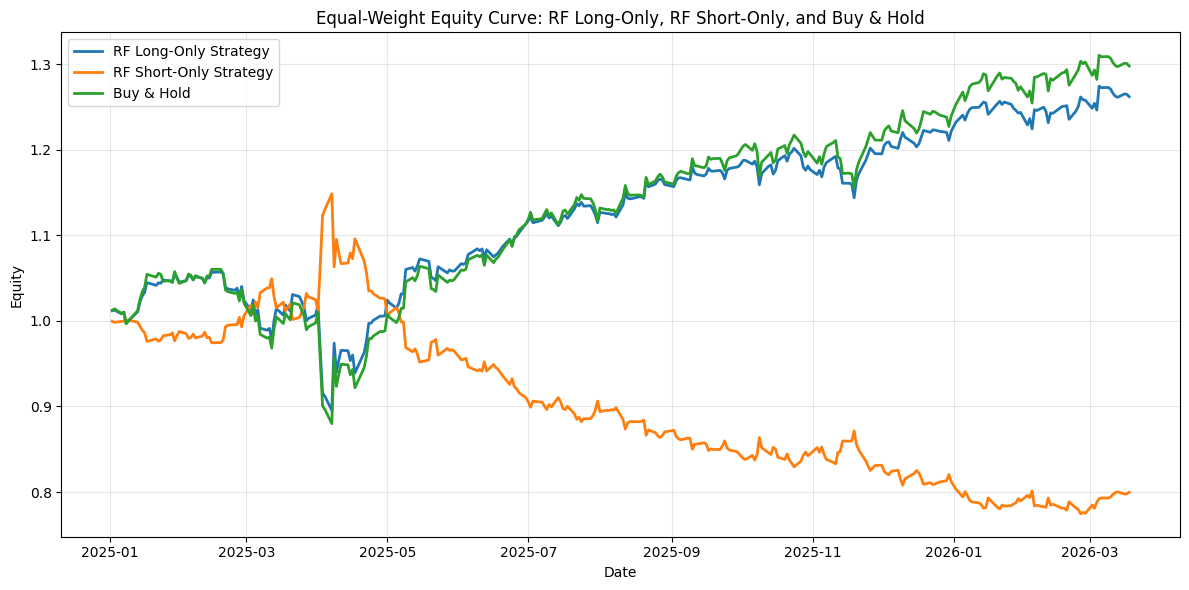

In [14]:
import matplotlib.pyplot as plt


def print_backtest_headline(summary_df, label):
    symbol_outperform_rate = float(summary_df.loc[0, "symbol_outperform_rate"])
    strategy_equal_weight_cum_return = float(summary_df.loc[0, "strategy_equal_weight_cum_return"])
    buy_hold_equal_weight_cum_return = float(summary_df.loc[0, "buy_hold_equal_weight_cum_return"])
    backtest_symbol_count = int(summary_df.loc[0, "backtest_symbols"])
    mean_active_positions = float(summary_df.loc[0, "mean_active_positions"])
    print(
        f"{label}: beat buy-and-hold on {symbol_outperform_rate:.1%} of symbols "
        f"({backtest_symbol_count} symbols) from {BACKTEST_START.date().isoformat()} onward."
    )
    print(
        f"{label}: equal-weight cumulative return {strategy_equal_weight_cum_return:.1%} | "
        f"buy-and-hold {buy_hold_equal_weight_cum_return:.1%} | "
        f"mean active positions {mean_active_positions:.1f}"
    )

label_config_summary_df = pd.DataFrame([
    {
        "min_market_cap": float(APP_CFG["universe"]["min_market_cap"]),
        "k_params": str(APP_CFG["labels"]["k_params"]),
        "min_profit_pct": float(APP_CFG["labels"]["min_profit_pct"]),
        "buy_execution": str(APP_CFG["labels"]["buy_execution"]),
        "sell_execution": str(APP_CFG["labels"]["sell_execution"]),
        "short_execution": str(APP_CFG["labels"]["short_execution"]),
        "cover_execution": str(APP_CFG["labels"]["cover_execution"]),
        "train_cutoff": TRAIN_CUTOFF.date().isoformat(),
        "backtest_start": BACKTEST_START.date().isoformat(),
    }
])
display(label_config_summary_df)


print_backtest_headline(rf_long_only_summary_df, "RF Long-only")
print_backtest_headline(rf_short_only_summary_df, "RF Short-only")

rf_long_plot_df = rf_long_only_daily_equal_weight_df.copy()
rf_long_plot_df["date"] = pd.to_datetime(rf_long_plot_df["date"], errors="coerce")
rf_long_plot_df = rf_long_plot_df.dropna(subset=["date"]).sort_values("date")
rf_short_plot_df = rf_short_only_daily_equal_weight_df.copy()
rf_short_plot_df["date"] = pd.to_datetime(rf_short_plot_df["date"], errors="coerce")
rf_short_plot_df = rf_short_plot_df.dropna(subset=["date"]).sort_values("date")

rf_plot_df = rf_long_plot_df[["date", "buy_hold_equity"]].merge(
    rf_short_plot_df[["date", "strategy_equity"]].rename(columns={"strategy_equity": "short_strategy_equity"}),
    on="date",
    how="inner",
)
rf_plot_df = rf_plot_df.merge(
    rf_long_plot_df[["date", "strategy_equity"]].rename(columns={"strategy_equity": "long_strategy_equity"}),
    on="date",
    how="inner",
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(rf_plot_df["date"], rf_plot_df["long_strategy_equity"], label="RF Long-Only Strategy", linewidth=2.0)
ax.plot(rf_plot_df["date"], rf_plot_df["short_strategy_equity"], label="RF Short-Only Strategy", linewidth=2.0)
ax.plot(rf_plot_df["date"], rf_plot_df["buy_hold_equity"], label="Buy & Hold", linewidth=2.0)
ax.set_title("Equal-Weight Equity Curve: RF Long-Only, RF Short-Only, and Buy & Hold")
ax.set_xlabel("Date")
ax.set_ylabel("Equity")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
